# Building Footprint Benchmarking: Regularization and Accuracy Assessment

This notebook compares one or more model-derived building footprint shapefiles
against a reference (ground truth) footprint layer.

**Workflow**
1. Load reference and model shapefiles, repair geometry, reproject to a common projected CRS
2. Regularize model polygons to right angles (orthogonalization with dominant-axis alignment)
3. Compute area based (pixel) metrics: IoU, precision, recall, F1, overall accuracy, kappa
4. Compute object based (instance) metrics using IoU matching at a threshold
5. Build confusion matrices and a comparison table
6. Export regularized layers and metrics

Both raw and regularized versions of each model are evaluated, so the effect of
regularization on accuracy is quantified rather than assumed.

**Note on overall accuracy.** Overall accuracy requires true negatives, which only
exist in the area based framework where background is an explicit class. At the object
level there is no true negative, so overall accuracy is not reported there. This is a
common source of confusion in footprint extraction papers and is worth stating explicitly
in the methods section.

In [1]:
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from shapely.geometry import Polygon, MultiPolygon
from shapely.affinity import rotate
from shapely.ops import unary_union

from rasterio.features import rasterize
from rasterio.transform import from_origin

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

try:
    from shapely import make_valid as _make_valid
except ImportError:
    _make_valid = None

print("geopandas", gpd.__version__)

geopandas 1.1.4


## 1. Configuration

Edit this cell only. Everything downstream reads from it.

In [5]:
# --- Inputs -----------------------------------------------------------------
REFERENCE_PATH = r"C:\Users\DiSharma\Desktop\Project\IndyMapShapefile\IndyBuildingTest.shp"

MODEL_PATHS = {
    "Blackshark.ai": r"C:\Users\DiSharma\Desktop\Project\Results\Blackshark\3inc_15cm\merged-vectors_3inc_15cm\vector_results_georef_891.gpkg",
    "Esri": r"C:\Users\DiSharma\Desktop\Project\Results\ESRI\ESRI Building Results\ESRI_3in_Build.shp",
    "U-Net34": r"C:\Users\DiSharma\Desktop\Project\Results\CustomModel\UnetResnet34\predicted_footprints (1).gpkg",
    "U-Net50": r"C:\Users\DiSharma\Desktop\Project\Results\CustomModel\UnetResnet50\predicted_footprints (1).gpkg",
    "DeepLabV3Plus34": r"C:\Users\DiSharma\Desktop\Project\Results\CustomModel\DeepLabV3PlusResnet34\predicted_footprints (1).gpkg",
    "DeepLabV3Plus50": r"C:\Users\DiSharma\Desktop\Project\Results\CustomModel\DeepLabV3PlusResnet50\predicted_footprints (1).gpkg",
    "LargeRun_Deeplab50": r"C:\Users\DiSharma\Desktop\Project\Results\CustomModel\LargeRun_DeepLabV3PlusResnet50\predicted_footprints (1).gpkg"
}

AOI_PATH = None          # optional polygon used to clip both layers, or None

# --- Projection and grid ----------------------------------------------------
TARGET_CRS = "EPSG:26916"   # UTM 16N (Indiana). Must be projected, units in metres
PIXEL_SIZE = 0.5            # metres, for the area based confusion matrix
MAX_PIXELS = 250_000_000    # guard against oversized rasters; grid is coarsened if exceeded

# --- Cleaning ---------------------------------------------------------------
MIN_AREA = 10.0             # m2, drop slivers below this in every layer

# --- Regularization ---------------------------------------------------------
SIMPLIFY_TOL = 0.30         # m, Douglas-Peucker tolerance applied before snapping
MIN_EDGE = 0.60             # m, edges shorter than this are collapsed
SNAP_ITERATIONS = 8         # orthogonalization passes
MAX_AREA_CHANGE = 0.30      # reject a regularized polygon if area changes more than this

# --- Matching ---------------------------------------------------------------
IOU_THRESHOLD = 0.50        # object level match threshold

# --- Output -----------------------------------------------------------------
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Demo mode --------------------------------------------------------------
# Set to True to generate synthetic data and run the whole notebook end to end
# without any input files. Useful for testing before pointing at real data.
USE_DEMO_DATA = False

## 2. Loading and geometry repair

In [6]:
def _to_polygons(geom):
    """Return a list of valid Polygon parts from any geometry."""
    if geom is None or geom.is_empty:
        return []
    if not geom.is_valid:
        geom = _make_valid(geom) if _make_valid is not None else geom.buffer(0)
    if geom.is_empty:
        return []
    if geom.geom_type == "Polygon":
        return [geom]
    if geom.geom_type == "MultiPolygon":
        return [g for g in geom.geoms if not g.is_empty]
    if geom.geom_type == "GeometryCollection":
        out = []
        for g in geom.geoms:
            out.extend(_to_polygons(g))
        return out
    return []


def load_polygons(path, target_crs=TARGET_CRS, min_area=MIN_AREA, aoi=None, name=""):
    """Read a polygon layer, repair it, explode to single parts, reproject and filter."""
    gdf = gpd.read_file(path)
    n_in = len(gdf)

    if gdf.crs is None:
        raise ValueError(f"{path} has no CRS defined. Assign one before running.")
    if target_crs is not None:
        gdf = gdf.to_crs(target_crs)

    parts = []
    for geom in gdf.geometry:
        parts.extend(_to_polygons(geom))
    gdf = gpd.GeoDataFrame(geometry=parts, crs=gdf.crs)

    if aoi is not None:
        gdf = gpd.clip(gdf, aoi)
        parts = []
        for geom in gdf.geometry:
            parts.extend(_to_polygons(geom))
        gdf = gpd.GeoDataFrame(geometry=parts, crs=gdf.crs)

    gdf = gdf[gdf.geometry.area >= min_area].reset_index(drop=True)
    print(f"{name or Path(path).stem:<18} {n_in:>7} features in -> {len(gdf):>7} clean parts")
    return gdf

### Optional: synthetic demo data

Generates a reference grid of rectangular and L-shaped buildings, then three
pseudo-models with different error signatures: vertex noise, systematic
oversegmentation, and undersegmentation with omissions.

In [8]:
def _l_shape(x, y, w, h, cut):
    return Polygon([(x, y), (x + w, y), (x + w, y + h - cut), (x + w - cut, y + h - cut),
                    (x + w - cut, y + h), (x, y + h)])


def make_demo_data(seed=42, nx=12, ny=12, spacing=40.0):
    rng = np.random.default_rng(seed)
    ref = []
    for i in range(nx):
        for j in range(ny):
            x0 = 500000 + i * spacing
            y0 = 4400000 + j * spacing
            w = rng.uniform(10, 22)
            h = rng.uniform(10, 22)
            ang = rng.uniform(0, 90)
            if rng.random() < 0.3:
                poly = _l_shape(x0, y0, w, h, min(w, h) * 0.4)
            else:
                poly = Polygon([(x0, y0), (x0 + w, y0), (x0 + w, y0 + h), (x0, y0 + h)])
            ref.append(rotate(poly, ang, origin="centroid"))
    ref = gpd.GeoDataFrame(geometry=ref, crs=TARGET_CRS)

    def jitter(gdf, noise, densify, drop, grow, seed):
        r = np.random.default_rng(seed)
        out = []
        for g in gdf.geometry:
            if r.random() < drop:
                continue
            g = g.buffer(grow).buffer(0)
            if g.is_empty:
                continue
            g = g.segmentize(densify)
            coords = np.array(g.exterior.coords)
            coords[:-1] += r.normal(0, noise, size=(len(coords) - 1, 2))
            coords[-1] = coords[0]
            parts = _to_polygons(Polygon(coords).buffer(0))
            if not parts:
                continue
            out.append(max(parts, key=lambda q: q.area))   # largest part only
        out = [p for p in out if p.area >= MIN_AREA]
        return gpd.GeoDataFrame(geometry=out, crs=gdf.crs)

    models = {
        "Blackshark.ai": jitter(ref, noise=0.45, densify=2.0, drop=0.08, grow=0.4, seed=1),
        "Esri": jitter(ref, noise=0.75, densify=1.5, drop=0.15, grow=-0.3, seed=2),
        "U-Net": jitter(ref, noise=0.60, densify=1.2, drop=0.05, grow=0.1, seed=3),
    }
    return ref, models


if USE_DEMO_DATA:
    reference, models_raw = make_demo_data()
    aoi = None
    print(f"{'reference':<18} {len(reference):>7} demo buildings")
    for k, v in models_raw.items():
        print(f"{k:<18} {len(v):>7} demo predictions")
else:
    aoi = gpd.read_file(AOI_PATH).to_crs(TARGET_CRS) if AOI_PATH else None
    reference = load_polygons(REFERENCE_PATH, aoi=aoi, name="reference")
    models_raw = {
        name: load_polygons(path, aoi=aoi, name=name)
        for name, path in MODEL_PATHS.items()
    }

reference              979 features in ->     945 clean parts
Blackshark.ai         1177 features in ->     979 clean parts
Esri                  1081 features in ->     876 clean parts
U-Net34               1007 features in ->     862 clean parts
U-Net50                992 features in ->     865 clean parts
DeepLabV3Plus34        959 features in ->     848 clean parts
DeepLabV3Plus50        983 features in ->     867 clean parts
LargeRun_Deeplab50     983 features in ->     880 clean parts


## 3. Right-angle regularization

Model footprints derived from raster segmentation carry a staircase boundary that
inflates vertex counts and depresses IoU against hand-digitized reference data.
The routine below does four things per polygon:

1. Estimate the dominant building axis from the longest edge of the minimum rotated rectangle
2. Rotate the polygon so that axis lies on the x axis, then simplify
3. Snap every edge to horizontal or vertical by iteratively averaging the shared
   coordinate of each edge's endpoints, which forces interior angles to 90 degrees
4. Collapse short edges, rebuild, rotate back

A polygon is rejected and replaced by a fallback if the result is invalid or if the
area changes by more than `MAX_AREA_CHANGE`. The fallback is the minimum rotated
rectangle when the shape is already close to rectangular, otherwise the original
geometry is retained. Rejections are counted and reported.

In [9]:
def _dominant_angle(poly):
    """Orientation of the longest edge of the minimum rotated rectangle, in degrees."""
    try:
        mrr = poly.minimum_rotated_rectangle
        coords = list(mrr.exterior.coords)[:-1]
    except Exception:
        return 0.0
    best_len, best_ang = -1.0, 0.0
    for i in range(len(coords)):
        p, q = coords[i], coords[(i + 1) % len(coords)]
        d = math.hypot(q[0] - p[0], q[1] - p[1])
        if d > best_len:
            best_len = d
            best_ang = math.degrees(math.atan2(q[1] - p[1], q[0] - p[0]))
    return best_ang % 90.0


def _collapse_short_edges(pts, min_edge):
    """Merge consecutive vertices closer together than min_edge."""
    if len(pts) < 4:
        return pts
    out = [pts[0]]
    for p in pts[1:]:
        if math.hypot(p[0] - out[-1][0], p[1] - out[-1][1]) >= min_edge:
            out.append(p)
    while len(out) > 3 and math.hypot(out[0][0] - out[-1][0], out[0][1] - out[-1][1]) < min_edge:
        out.pop()
    return np.array(out)


def _snap_ring(coords, iterations=SNAP_ITERATIONS):
    """Force a closed ring to right angles by iterative coordinate averaging.

    Each edge is classified as horizontal or vertical from its dominant component.
    Horizontal edges pull both endpoints to a shared y, vertical edges to a shared x.
    Repeating this converges to a rectilinear ring.
    """
    pts = np.asarray(coords, dtype=float)
    if len(pts) > 1 and np.allclose(pts[0], pts[-1]):
        pts = pts[:-1]
    n = len(pts)
    if n < 4:
        return pts

    for _ in range(iterations):
        acc_x = np.zeros(n); cnt_x = np.zeros(n)
        acc_y = np.zeros(n); cnt_y = np.zeros(n)
        for i in range(n):
            j = (i + 1) % n
            dx = pts[j, 0] - pts[i, 0]
            dy = pts[j, 1] - pts[i, 1]
            if abs(dx) >= abs(dy):                      # horizontal edge
                ym = 0.5 * (pts[i, 1] + pts[j, 1])
                acc_y[i] += ym; cnt_y[i] += 1
                acc_y[j] += ym; cnt_y[j] += 1
            else:                                       # vertical edge
                xm = 0.5 * (pts[i, 0] + pts[j, 0])
                acc_x[i] += xm; cnt_x[i] += 1
                acc_x[j] += xm; cnt_x[j] += 1
        new = pts.copy()
        mx = cnt_x > 0
        my = cnt_y > 0
        new[mx, 0] = acc_x[mx] / cnt_x[mx]
        new[my, 1] = acc_y[my] / cnt_y[my]
        if np.max(np.abs(new - pts)) < 1e-4:
            pts = new
            break
        pts = new
    return pts


def _rebuild_rectilinear(pts, min_edge):
    """Reconstruct the ring as exactly rectilinear.

    Consecutive edges sharing an orientation are merged into a single length weighted
    line, then vertices are recomputed as intersections of consecutive perpendicular
    lines. This guarantees exact 90 degree interior angles rather than approximate ones.
    Short edges are removed by dropping the offending line pair and rebuilding.
    """
    def lines_to_verts(lines):
        m = len(lines)
        verts = []
        for k in range(m):
            o1, v1 = lines[k]
            o2, v2 = lines[(k + 1) % m]
            if o1 == o2:
                return None
            verts.append((v2, v1) if o1 == "H" else (v1, v2))
        return np.array(verts, dtype=float)

    for _ in range(6):
        n = len(pts)
        if n < 4:
            return None

        orient = []
        for i in range(n):
            j = (i + 1) % n
            dx = pts[j, 0] - pts[i, 0]
            dy = pts[j, 1] - pts[i, 1]
            orient.append("H" if abs(dx) >= abs(dy) else "V")

        start = next((i for i in range(n) if orient[i] != orient[i - 1]), None)
        if start is None:
            return None

        runs, i, seen = [], start, 0
        while seen < n:
            o = orient[i % n]
            idxs = []
            while seen < n and orient[i % n] == o:
                idxs.append(i % n)
                i += 1
                seen += 1
            runs.append((o, idxs))

        if len(runs) % 2 == 1:
            if runs[0][0] == runs[-1][0]:
                runs[0] = (runs[0][0], runs[-1][1] + runs[0][1])
                runs.pop()
            else:
                return None
        if len(runs) < 4:
            return None

        lines = []
        for o, idxs in runs:
            num = den = 0.0
            for e in idxs:
                a, b = pts[e], pts[(e + 1) % n]
                L = math.hypot(b[0] - a[0], b[1] - a[1]) + 1e-9
                val = 0.5 * (a[1] + b[1]) if o == "H" else 0.5 * (a[0] + b[0])
                num += val * L
                den += L
            lines.append((o, num / den))

        verts = lines_to_verts(lines)
        if verts is None:
            return None

        m = len(verts)
        seg = [math.hypot(*(verts[(k + 1) % m] - verts[k])) for k in range(m)]
        if m <= 4 or min(seg) >= min_edge:
            return verts

        k = int(np.argmin(seg))
        drop = {(k + 1) % m, (k + 2) % m}
        kept = [lines[t] for t in range(m) if t not in drop]
        if len(kept) < 4:
            return verts
        nxt = lines_to_verts(kept)
        if nxt is None:
            return verts
        pts = nxt

    return pts


def _regularize_ring(coords, simplify_tol, min_edge):
    pts = np.asarray(coords, dtype=float)
    if len(pts) > 1 and np.allclose(pts[0], pts[-1]):
        pts = pts[:-1]
    if len(pts) < 4:
        return None
    pts = _snap_ring(pts)
    pts = _collapse_short_edges(pts, min_edge)
    if len(pts) < 4:
        return None
    pts = _snap_ring(pts, iterations=3)
    exact = _rebuild_rectilinear(pts, min_edge)
    return exact if exact is not None and len(exact) >= 4 else pts


def regularize_polygon(poly, simplify_tol=SIMPLIFY_TOL, min_edge=MIN_EDGE,
                       max_area_change=MAX_AREA_CHANGE):
    """Return (regularized_polygon, status) where status is ok, fallback_mrr or fallback_original."""
    if poly is None or poly.is_empty:
        return poly, "empty"

    theta = _dominant_angle(poly)
    origin = poly.centroid
    work = rotate(poly, -theta, origin=origin)
    work = work.simplify(simplify_tol, preserve_topology=True)

    parts = _to_polygons(work)
    if len(parts) != 1:
        return _fallback(poly)
    work = parts[0]

    ext = _regularize_ring(work.exterior.coords, simplify_tol, min_edge)
    if ext is None:
        return _fallback(poly)

    holes = []
    for ring in work.interiors:
        h = _regularize_ring(ring.coords, simplify_tol, min_edge)
        if h is not None and len(h) >= 4:
            hp = Polygon(h)
            if hp.is_valid and hp.area >= min_edge ** 2:
                holes.append(h)

    try:
        new = Polygon(ext, holes)
    except Exception:
        return _fallback(poly)

    if not new.is_valid:
        new = new.buffer(0)
    parts = _to_polygons(new)
    if not parts:
        return _fallback(poly)
    new = max(parts, key=lambda g: g.area)

    out = rotate(new, theta, origin=origin)
    if out.is_empty or poly.area <= 0:
        return _fallback(poly)
    if abs(out.area - poly.area) / poly.area > max_area_change:
        return _fallback(poly)
    return out, "ok"


def _fallback(poly):
    """Minimum rotated rectangle when the shape is already near rectangular, else original."""
    try:
        mrr = poly.minimum_rotated_rectangle
        if mrr.area > 0 and poly.area / mrr.area > 0.85:
            return mrr, "fallback_mrr"
    except Exception:
        pass
    return poly, "fallback_original"


def regularize_gdf(gdf, **kwargs):
    geoms, statuses = [], []
    for g in gdf.geometry:
        ng, st = regularize_polygon(g, **kwargs)
        geoms.append(ng)
        statuses.append(st)
    out = gdf.copy()
    out["geometry"] = geoms
    out["reg_status"] = statuses
    out["src_idx"] = np.arange(len(gdf))
    out = out[~out.geometry.is_empty].reset_index(drop=True)
    return out


def _vertex_count(gdf):
    n = 0
    for g in gdf.geometry:
        for p in _to_polygons(g):
            n += len(p.exterior.coords) - 1
            n += sum(len(r.coords) - 1 for r in p.interiors)
    return n

In [10]:
models_reg = {}
reg_report = []

for name, gdf in models_raw.items():
    reg = regularize_gdf(gdf)
    models_reg[name] = reg
    v_before = _vertex_count(gdf)
    v_after = _vertex_count(reg)
    counts = reg["reg_status"].value_counts().to_dict()
    reg_report.append({
        "Model": name,
        "Polygons": len(reg),
        "Vertices before": v_before,
        "Vertices after": v_after,
        "Vertex reduction %": 100 * (1 - v_after / v_before) if v_before else np.nan,
        "Mean vertices/bldg before": v_before / max(len(gdf), 1),
        "Mean vertices/bldg after": v_after / max(len(reg), 1),
        "Area change %": 100 * (reg.geometry.area.sum() / gdf.geometry.area.sum() - 1),
        "Orthogonalized": counts.get("ok", 0),
        "Fallback MRR": counts.get("fallback_mrr", 0),
        "Fallback original": counts.get("fallback_original", 0),
    })

reg_df = pd.DataFrame(reg_report)
print("\nRegularization summary\n")
print(reg_df.round(2).to_string(index=False))


Regularization summary

             Model  Polygons  Vertices before  Vertices after  Vertex reduction %  Mean vertices/bldg before  Mean vertices/bldg after  Area change %  Orthogonalized  Fallback MRR  Fallback original
     Blackshark.ai       979            13130            7148               45.56                      13.41                      7.30          -1.19             579           356                 44
              Esri       876             8552            5895               31.07                       9.76                      6.73          -1.34             529           325                 22
           U-Net34       862           162308           10418               93.58                     188.29                     12.09          -1.89             714           101                 47
           U-Net50       865           154734            9520               93.85                     178.88                     11.01          -1.96             732            92

### Visual check

A handful of polygons drawn before and after regularization. Right angles should be
visible while the overall footprint and orientation are preserved.

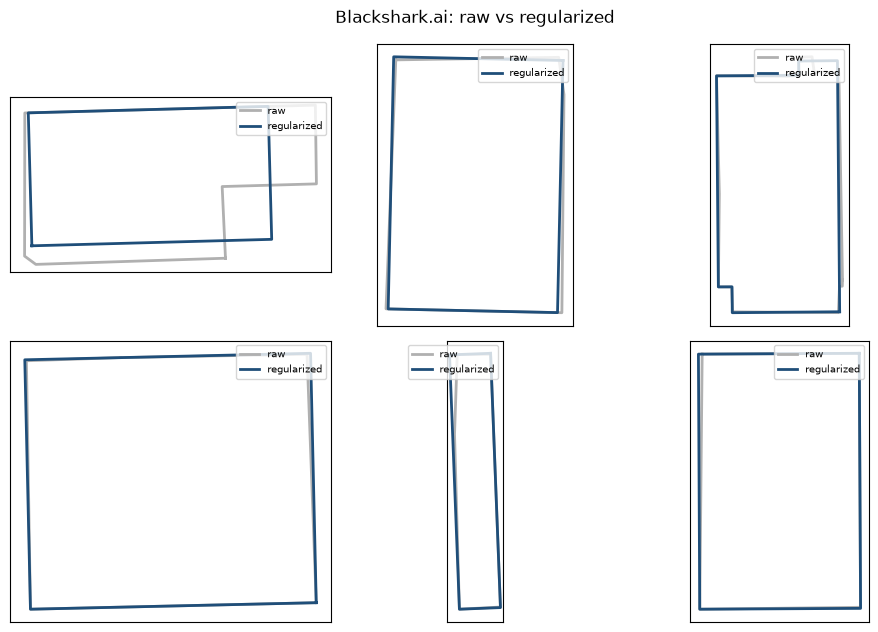

In [11]:
def plot_regularization(name, n=6, seed=0):
    raw = models_raw[name]
    reg = models_reg[name]
    k = min(n, len(reg))
    idx = np.random.default_rng(seed).choice(len(reg), size=k, replace=False)
    ncol = 3
    nrow = int(np.ceil(k / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3.2 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, i in zip(axes, idx):
        b = reg.geometry.iloc[i]
        a = raw.geometry.iloc[int(reg["src_idx"].iloc[i])]
        for geom, color, lab in [(a, "#b0b0b0", "raw"), (b, "#1f4e79", "regularized")]:
            for p in _to_polygons(geom):
                x, y = p.exterior.xy
                ax.plot(x, y, color=color, lw=2, label=lab)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        handles, labels = ax.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        ax.legend(uniq.values(), uniq.keys(), fontsize=7, loc="upper right")
    for ax in axes[k:]:
        ax.axis("off")
    fig.suptitle(f"{name}: raw vs regularized", fontsize=12)
    fig.tight_layout()
    plt.show()


plot_regularization(list(models_raw)[0])

## 4. Area based metrics

Both layers are dissolved and burned onto a shared grid. Every cell falls into one
of four classes, giving a standard binary confusion matrix:

| | Reference building | Reference background |
|---|---|---|
| **Predicted building** | TP | FP |
| **Predicted background** | FN | TN |

From these: IoU = TP / (TP + FP + FN), precision = TP / (TP + FP),
recall = TP / (TP + FN), F1 = 2PR / (P + R), overall accuracy = (TP + TN) / N.

Because background dominates, overall accuracy will sit above 0.95 for almost any
model and carries little discriminating power. IoU and F1 are the meaningful numbers.
Cohen's kappa is included since it corrects for the chance agreement that inflates OA.

In [12]:
def build_grid(gdfs, pixel_size=PIXEL_SIZE, pad=5.0, max_pixels=MAX_PIXELS):
    bounds = np.array([g.total_bounds for g in gdfs if len(g)])
    minx, miny = bounds[:, 0].min() - pad, bounds[:, 1].min() - pad
    maxx, maxy = bounds[:, 2].max() + pad, bounds[:, 3].max() + pad

    while True:
        width = int(np.ceil((maxx - minx) / pixel_size))
        height = int(np.ceil((maxy - miny) / pixel_size))
        if width * height <= max_pixels:
            break
        pixel_size *= 2
        print(f"Grid too large, coarsening pixel size to {pixel_size} m")

    transform = from_origin(minx, maxy, pixel_size, pixel_size)
    print(f"Grid: {width} x {height} cells at {pixel_size} m ({width*height/1e6:.1f} Mpx)")
    return transform, (height, width), pixel_size


def burn(gdf, transform, shape):
    geoms = [g for g in gdf.geometry if g is not None and not g.is_empty]
    if not geoms:
        return np.zeros(shape, dtype=np.uint8)
    return rasterize([(g, 1) for g in geoms], out_shape=shape, transform=transform,
                     fill=0, dtype=np.uint8, all_touched=False)


def area_metrics(pred_arr, ref_arr):
    pred = pred_arr.astype(bool)
    ref = ref_arr.astype(bool)
    tp = int(np.count_nonzero(pred & ref))
    fp = int(np.count_nonzero(pred & ~ref))
    fn = int(np.count_nonzero(~pred & ref))
    tn = int(pred.size - tp - fp - fn)

    eps = 1e-12
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    oa = (tp + tn) / (tp + tn + fp + fn + eps)

    n = tp + tn + fp + fn
    pe = ((tp + fp) * (tp + fn) + (fn + tn) * (fp + tn)) / (n ** 2 + eps)
    kappa = (oa - pe) / (1 - pe + eps)

    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "IoU": iou, "Precision": precision, "Recall": recall,
            "F1": f1, "Overall accuracy": oa, "Kappa": kappa}

## 5. Object based metrics

Predicted and reference polygons are matched one to one by greedy descending IoU,
accepting a pair only above `IOU_THRESHOLD`. Unmatched predictions are commission
errors, unmatched reference buildings are omission errors. Mean IoU is reported over
matched pairs only, so it should always be read alongside the recall figure.

In [13]:
def object_metrics(pred_gdf, ref_gdf, iou_threshold=IOU_THRESHOLD):
    n_pred, n_ref = len(pred_gdf), len(ref_gdf)
    if n_pred == 0 or n_ref == 0:
        return {"TP": 0, "FP": n_pred, "FN": n_ref, "Precision": 0.0, "Recall": 0.0,
                "F1": 0.0, "Mean IoU (matched)": np.nan, "N pred": n_pred, "N ref": n_ref}

    sindex = ref_gdf.sindex
    candidates = []
    ref_geoms = ref_gdf.geometry.values
    for i, pg in enumerate(pred_gdf.geometry.values):
        for j in sindex.query(pg, predicate="intersects"):
            rg = ref_geoms[j]
            inter = pg.intersection(rg).area
            if inter <= 0:
                continue
            union = pg.area + rg.area - inter
            if union <= 0:
                continue
            iou = inter / union
            if iou >= iou_threshold:
                candidates.append((iou, i, int(j)))

    candidates.sort(reverse=True)
    used_p, used_r, matched = set(), set(), []
    for iou, i, j in candidates:
        if i in used_p or j in used_r:
            continue
        used_p.add(i); used_r.add(j); matched.append(iou)

    tp = len(matched)
    fp = n_pred - tp
    fn = n_ref - tp
    eps = 1e-12
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    return {"TP": tp, "FP": fp, "FN": fn,
            "Precision": precision, "Recall": recall, "F1": f1,
            "Mean IoU (matched)": float(np.mean(matched)) if matched else np.nan,
            "N pred": n_pred, "N ref": n_ref}

## 6. Run the evaluation

In [14]:
all_layers = [reference] + list(models_raw.values()) + list(models_reg.values())
transform, shape, used_pixel = build_grid(all_layers)

ref_arr = burn(reference, transform, shape)
print(f"Reference building pixels: {int(ref_arr.sum()):,} "
      f"({100 * ref_arr.mean():.2f}% of grid)")

area_rows, object_rows, cm_store = [], [], {}

variants = []
for name in models_raw:
   # variants.append((name, "Raw", models_raw[name]))
    variants.append((name, "Regularized", models_reg[name]))

for name, variant, gdf in variants:
    label = f"{name} ({variant})"
    pred_arr = burn(gdf, transform, shape)

    am = area_metrics(pred_arr, ref_arr)
    om = object_metrics(gdf, reference)

    cm_store[label] = {"area": am, "object": om}
    area_rows.append({"Model": name, "Variant": variant, **am})
    object_rows.append({"Model": name, "Variant": variant, **om})
    print(f"done: {label}")

    del pred_arr

area_df = pd.DataFrame(area_rows)
object_df = pd.DataFrame(object_rows)

Grid too large, coarsening pixel size to 1.0 m
Grid: 8142 x 25104 cells at 1.0 m (204.4 Mpx)
Reference building pixels: 265,322 (0.13% of grid)
done: Blackshark.ai (Regularized)
done: Esri (Regularized)
done: U-Net34 (Regularized)
done: U-Net50 (Regularized)
done: DeepLabV3Plus34 (Regularized)
done: DeepLabV3Plus50 (Regularized)
done: LargeRun_Deeplab50 (Regularized)


## 7. Results tables

In [21]:
area_cols = ["Model", "Variant", "IoU", "Precision", "Recall", "F1",
             "Overall accuracy", "Kappa", "TP", "FP", "FN", "TN"]
obj_cols = ["Model", "Variant", "Precision", "Recall", "F1",
            "Mean IoU (matched)", "TP", "FP", "FN", "N pred", "N ref"]

area_out = area_df[area_cols].copy()
obj_out = object_df[obj_cols].copy()

float_cols_a = ["IoU", "Precision", "Recall", "F1", "Overall accuracy", "Kappa"]
float_cols_o = ["Precision", "Recall", "F1", "Mean IoU (matched)"]
area_out[float_cols_a] = area_out[float_cols_a].round(4)
obj_out[float_cols_o] = obj_out[float_cols_o].round(4)

print("=" * 110)
print(f"AREA BASED ACCURACY  (grid {used_pixel} m)")
print("=" * 110)
print(area_out.to_string(index=False))

print()
print("=" * 110)
print(f"OBJECT BASED ACCURACY  (IoU threshold {IOU_THRESHOLD})")
print("=" * 110)
print(obj_out.to_string(index=False))

AREA BASED ACCURACY  (grid 1.0 m)
             Model     Variant    IoU  Precision  Recall     F1  Overall accuracy  Kappa     TP    FP    FN        TN
     Blackshark.ai Regularized 0.8009     0.9037  0.8757 0.8895            0.9997 0.8893 232330 24749 32992 204106697
              Esri Regularized 0.5719     0.8544  0.6337 0.7277            0.9994 0.7274 168133 28645 97189 204102801
           U-Net34 Regularized 0.8038     0.9022  0.8806 0.8912            0.9997 0.8911 233635 25335 31687 204106111
           U-Net50 Regularized 0.7828     0.8971  0.8600 0.8781            0.9997 0.8780 228179 26184 37143 204105262
   DeepLabV3Plus34 Regularized 0.8136     0.8910  0.9034 0.8972            0.9997 0.8971 239704 29311 25618 204102135
   DeepLabV3Plus50 Regularized 0.8145     0.8988  0.8967 0.8977            0.9997 0.8976 237906 26784 27416 204104662
LargeRun_Deeplab50 Regularized 0.8508     0.9130  0.9258 0.9194            0.9998 0.9193 245630 23397 19692 204108049

OBJECT BASED ACCURACY

### Effect of regularization

Positive values indicate the regularized layer scored higher than the raw layer.

In [16]:
# delta_rows = []
# for name in models_raw:
#     a_raw = area_df[(area_df.Model == name) & (area_df.Variant == "Raw")].iloc[0]
#     a_reg = area_df[(area_df.Model == name) & (area_df.Variant == "Regularized")].iloc[0]
#     o_raw = object_df[(object_df.Model == name) & (object_df.Variant == "Raw")].iloc[0]
#     o_reg = object_df[(object_df.Model == name) & (object_df.Variant == "Regularized")].iloc[0]
#     delta_rows.append({
#         "Model": name,
#         "d IoU (area)": a_reg["IoU"] - a_raw["IoU"],
#         "d F1 (area)": a_reg["F1"] - a_raw["F1"],
#         "d Precision (area)": a_reg["Precision"] - a_raw["Precision"],
#         "d Recall (area)": a_reg["Recall"] - a_raw["Recall"],
#         "d F1 (object)": o_reg["F1"] - o_raw["F1"],
#         "d Mean IoU (object)": o_reg["Mean IoU (matched)"] - o_raw["Mean IoU (matched)"],
#     })

# delta_df = pd.DataFrame(delta_rows)
# print("Change from raw to regularized\n")
# print(delta_df.round(4).to_string(index=False))

## 8. Confusion matrices

Two panels per model variant. The left panel holds raw pixel counts, the right holds
the same matrix normalized by reference class so the omission and commission rates
can be read directly off the diagonal.

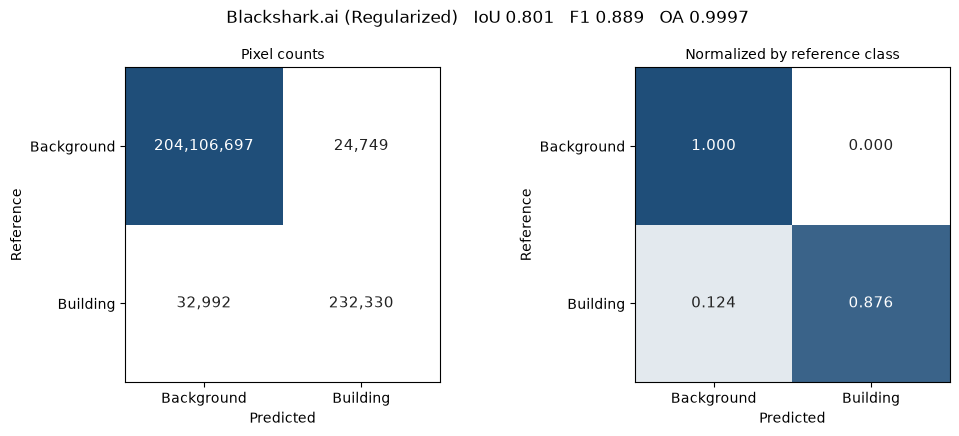

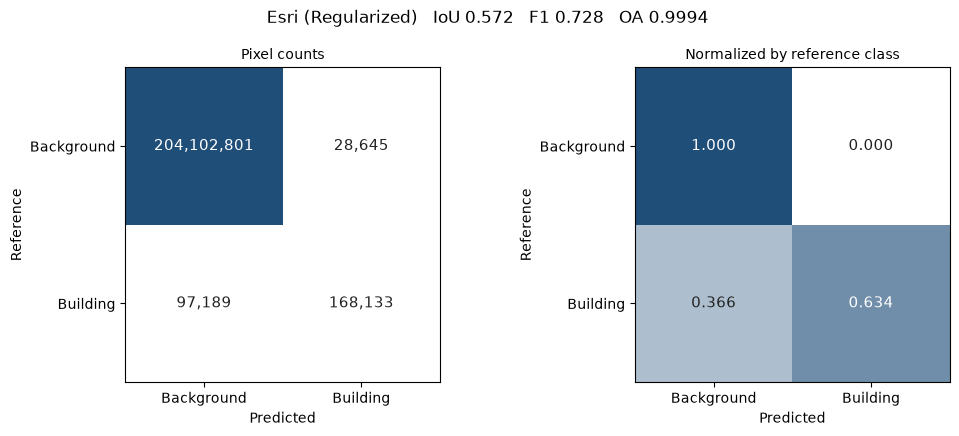

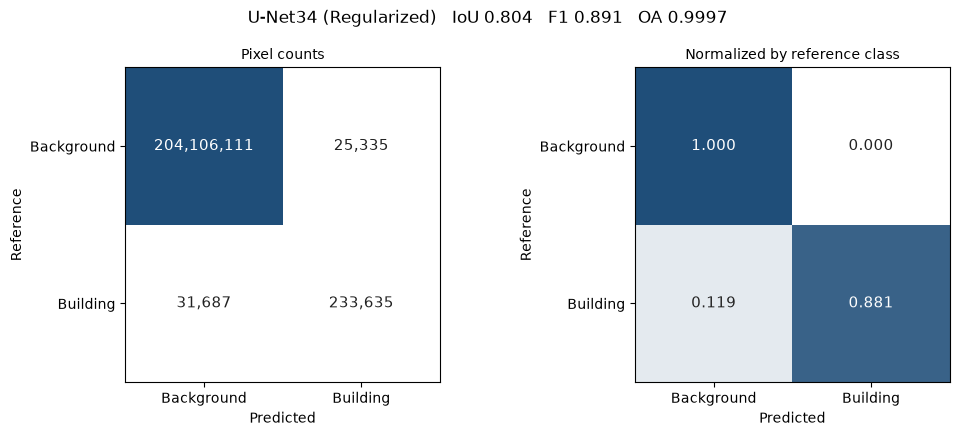

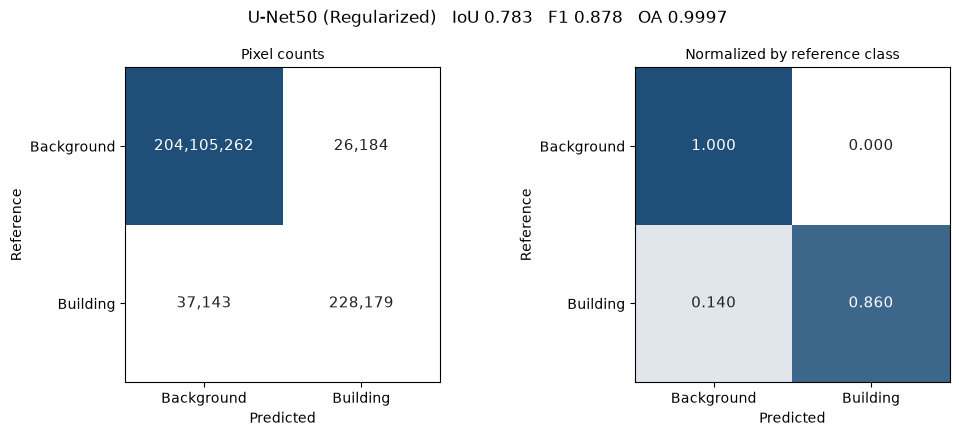

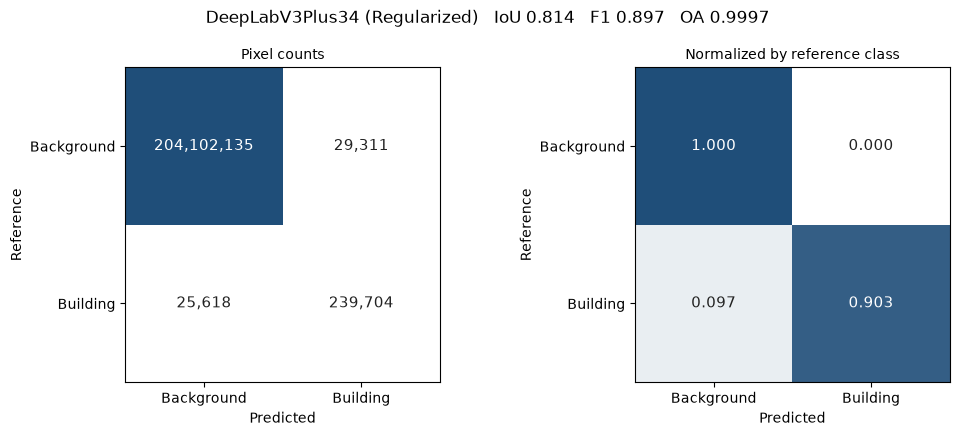

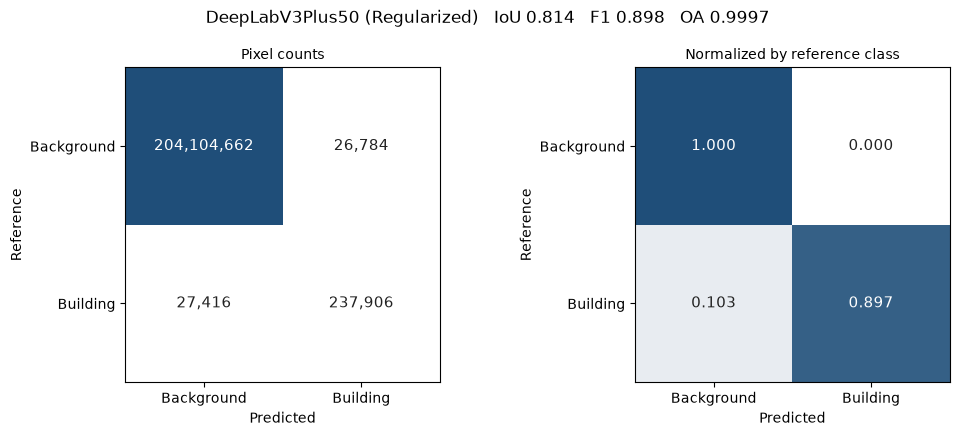

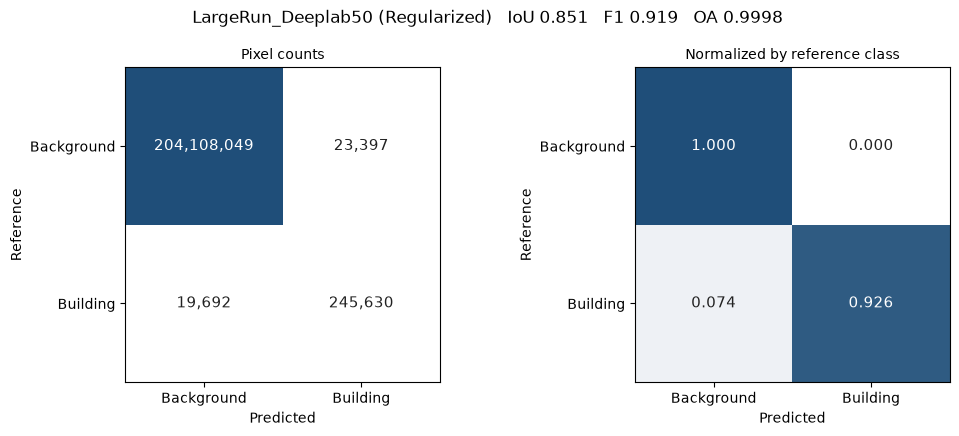

In [17]:
def plot_confusion(label, area_m, save=True):
    cm = np.array([[area_m["TN"], area_m["FP"]],
                   [area_m["FN"], area_m["TP"]]], dtype=float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    classes = ["Background", "Building"]
    cmap = LinearSegmentedColormap.from_list("nb", ["#ffffff", "#1f4e79"])

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
    for ax, mat, title, fmt in [
        (axes[0], cm, "Pixel counts", "{:,.0f}"),
        (axes[1], cm_norm, "Normalized by reference class", "{:.3f}"),
    ]:
        show = mat / mat.max() if title.startswith("Pixel") else mat
        ax.imshow(show, cmap=cmap, vmin=0, vmax=1)
        ax.set_xticks([0, 1], classes)
        ax.set_yticks([0, 1], classes)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Reference")
        ax.set_title(title, fontsize=10)
        for i in range(2):
            for j in range(2):
                v = show[i, j]
                ax.text(j, i, fmt.format(mat[i, j]), ha="center", va="center",
                        color="white" if v > 0.5 else "#222222", fontsize=11)
    fig.suptitle(
        f"{label}   IoU {area_m['IoU']:.3f}   F1 {area_m['F1']:.3f}   OA {area_m['Overall accuracy']:.4f}",
        fontsize=12)
    fig.tight_layout()
    if save:
        safe = label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "")
        fig.savefig(OUT_DIR / f"confusion_{safe}.png", dpi=200, bbox_inches="tight")
    plt.show()


for label, m in cm_store.items():
    plot_confusion(label, m["area"])

### Object level error composition

True negatives do not exist at the object level, so this is shown as a bar breakdown
of matched, commission and omission counts rather than a 2 x 2 matrix.

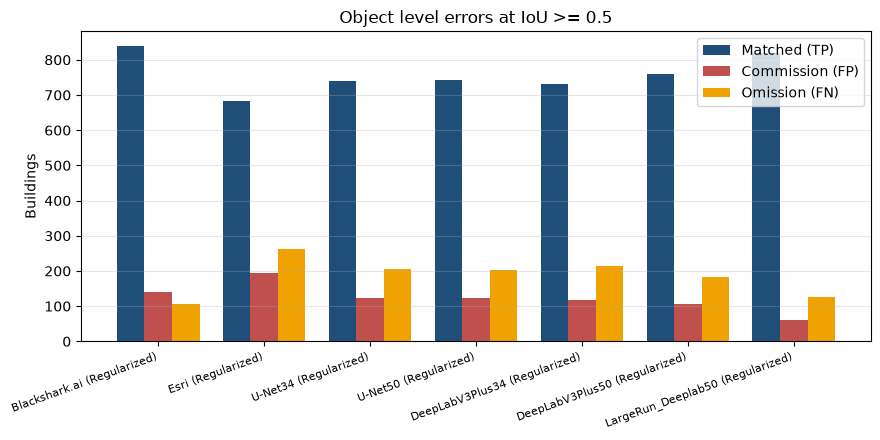

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = list(cm_store.keys())
tp = [cm_store[k]["object"]["TP"] for k in labels]
fp = [cm_store[k]["object"]["FP"] for k in labels]
fn = [cm_store[k]["object"]["FN"] for k in labels]
x = np.arange(len(labels))
w = 0.26
ax.bar(x - w, tp, w, label="Matched (TP)", color="#1f4e79")
ax.bar(x, fp, w, label="Commission (FP)", color="#c0504d")
ax.bar(x + w, fn, w, label="Omission (FN)", color="#f0a202")
ax.set_xticks(x, labels, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Buildings")
ax.set_title(f"Object level errors at IoU >= {IOU_THRESHOLD}")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "object_errors.png", dpi=200, bbox_inches="tight")
plt.show()

### IoU sensitivity

Object level F1 depends strongly on the matching threshold. Reporting the curve rather
than a single value at 0.5 is more defensible in a benchmarking paper.

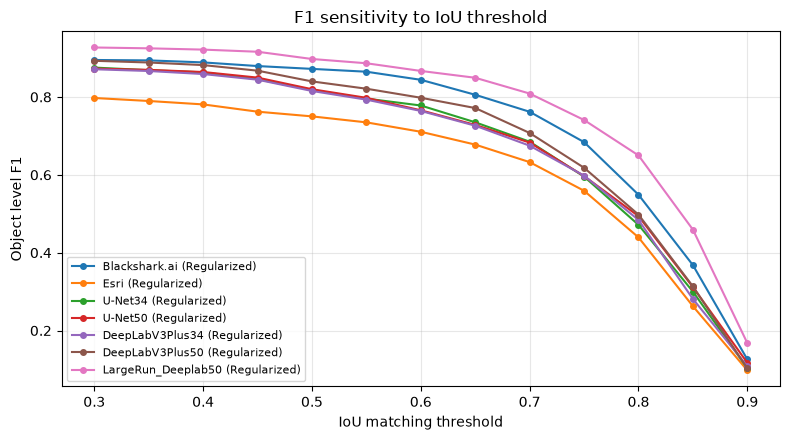

In [19]:
thresholds = np.arange(0.3, 0.91, 0.05)
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, variant, gdf in variants:
    f1s = [object_metrics(gdf, reference, t)["F1"] for t in thresholds]
    ax.plot(thresholds, f1s, marker="o", ms=4,
            ls="-" if variant == "Regularized" else "--",
            label=f"{name} ({variant})")
ax.set_xlabel("IoU matching threshold")
ax.set_ylabel("Object level F1")
ax.set_title("F1 sensitivity to IoU threshold")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "f1_vs_iou_threshold.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Export

In [20]:
area_out.to_csv(OUT_DIR / "metrics_area_based.csv", index=False)
obj_out.to_csv(OUT_DIR / "metrics_object_based.csv", index=False)
#delta_df.round(4).to_csv(OUT_DIR / "regularization_effect.csv", index=False)
reg_df.round(3).to_csv(OUT_DIR / "regularization_summary.csv", index=False)

gpkg = OUT_DIR / "regularized_footprints.gpkg"
for name, gdf in models_reg.items():
    layer = name.replace(".", "_").replace(" ", "_")
    gdf.to_file(gpkg, layer=layer, driver="GPKG")
    gdf.to_file(OUT_DIR / f"{layer}_regularized.shp")

print("Written to", OUT_DIR.resolve())
for p in sorted(OUT_DIR.iterdir()):
    print(" ", p.name)

Written to C:\Users\DiSharma\Desktop\Project\CustomModel\building-extraction\outputs
  Blackshark_ai_regularized.cpg
  Blackshark_ai_regularized.dbf
  Blackshark_ai_regularized.prj
  Blackshark_ai_regularized.shp
  Blackshark_ai_regularized.shp.CBLXCY3.10184.13280.sr.lock
  Blackshark_ai_regularized.shp.CBLXCY3.22728.13280.sr.lock
  Blackshark_ai_regularized.shp.CBLXCY3.37652.13280.sr.lock
  Blackshark_ai_regularized.shp.CBLXCY3.38160.13280.sr.lock
  Blackshark_ai_regularized.shx
  confusion_Blacksharkai_Raw.png
  confusion_Blacksharkai_Regularized.png
  confusion_DeepLabV3Plus34_Regularized.png
  confusion_DeepLabV3Plus50_Regularized.png
  confusion_Esri_Raw.png
  confusion_Esri_Regularized.png
  confusion_LargeRun_Deeplab50_Regularized.png
  confusion_U-Net34_Regularized.png
  confusion_U-Net50_Regularized.png
  confusion_U-Net_Raw.png
  confusion_U-Net_Regularized.png
  DeepLabV3Plus34_regularized.cpg
  DeepLabV3Plus34_regularized.dbf
  DeepLabV3Plus34_regularized.prj
  DeepLabV3Plu